### Load the packages

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/var/folders/q_/fz2ylcb14dqcs8bp2t8hjz6m0000gn/T/ipykernel_24229/976157922.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
import os 
os.getcwd()

'/Users/contessina/Documents/my_projects/RR'

In [5]:
path = '/Users/contessina/Documents/my_projects/RR/data/'

### Load the data and precompute the daily returns

In [6]:
df_ru000A103331 = pd.read_excel(f'{path}test_local.xlsx')

In [7]:
df_ru000A103331.head(2)

,Дата,Пай (₽),СЧА (₽),Выплаченный (зарезервированный) по инвестиционным паям инвестиционный доход (₽)
0,2022-07-11 03:00:00,"971,54","592 814 089,48",NaN
1,2022-07-12 03:00:00,"966,70","588 907 522,14",NaN


In [8]:
df_ru000A103331['ΔLAST за день, %'] = df_ru000A103331['СЧА'].sort_index(ascending=False).pct_change().dropna()

KeyError: 'СЧА'

In [ ]:
df_ru000A103331.head(2)

,Дата,СЧА на акцию,"ΔLAST за день, %",СЧА
0,07.07.2025,54015.60,-0.009590,1.460519e+10
1,04.07.2025,54528.25,-0.010189,1.474661e+10


In [ ]:
returns = df_ru000A103331['ΔLAST за день, %'].iloc[:-1]

### Historical VaR

In [ ]:
confidence_level = 0.95
var = np.percentile(returns, (1 - confidence_level) * 100)
print(f"Value at Risk (VaR) at {confidence_level*100}% confidence level is {var:.2%}")

Value at Risk (VaR) at 95.0% confidence level is -2.33%


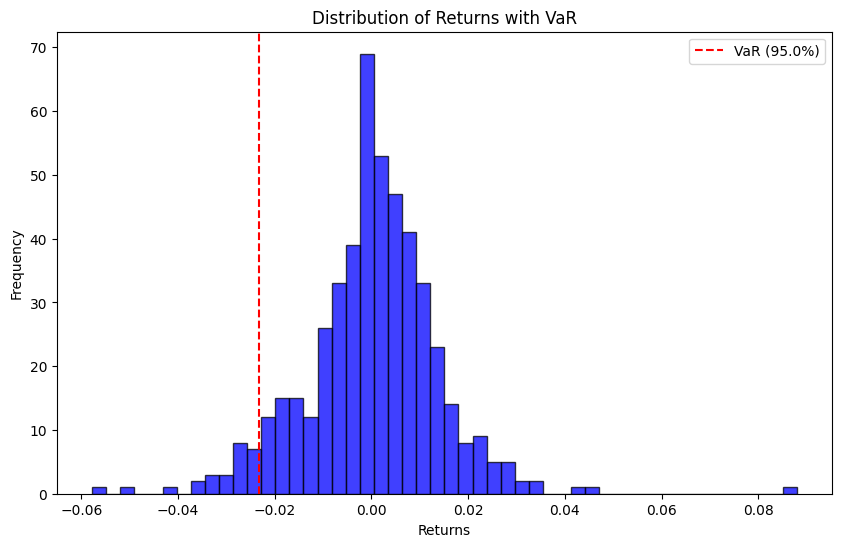

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, alpha=0.75, color='blue', edgecolor='black')
plt.axvline(x=var, color='red', linestyle='--', label=f'VaR ({confidence_level*100}%)')
plt.title('Distribution of Returns with VaR')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
#VaR annualization
period = 252 # n of days
var_1y = var * math.sqrt(period)
print(f"1Y Value at Risk (VaR) at {confidence_level*100}% confidence level is {var_1y:.2%}")

1Y Value at Risk (VaR) at 95.0% confidence level is -36.95%


### CVaR aka Expected Shortfall

In [ ]:
var_threshold = np.percentile(returns, (1 - confidence_level) * 100)
tail_losses = returns[returns < var_threshold]

In [ ]:
cvar = tail_losses.mean()
print(f"Conditional Value at Risk (CVaR) at {confidence_level*100}% confidence level is {cvar:.2%}")

Conditional Value at Risk (CVaR) at 95.0% confidence level is -3.09%


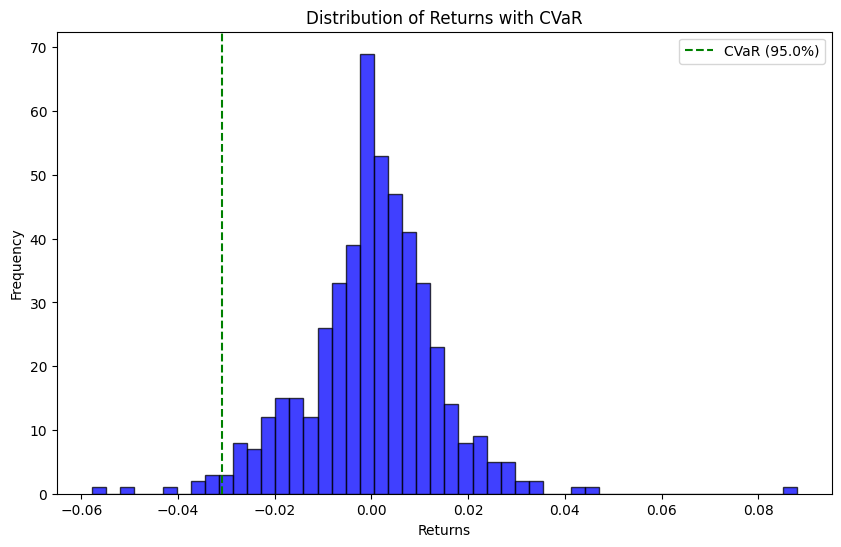

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, alpha=0.75, color='blue', edgecolor='black')
# plt.axvline(x=var, color='red', linestyle='--', label=f'VaR ({confidence_level*100}%)')
plt.axvline(x=cvar, color='green', linestyle='--', label=f'CVaR ({confidence_level*100}%)')
plt.title('Distribution of Returns with CVaR')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Normality Tests

#### Q-Q plot

In [ ]:
import statsmodels.api as sm

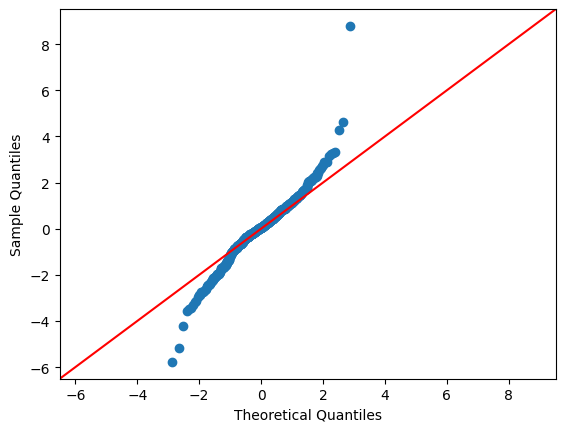

In [ ]:
#create Q-Q plot with 45-degree line added to plot (brought to % from absolute values, as the abs change is too close to 0.0)
fig = sm.qqplot(returns*100, line='45')

plt.show()

#### Shapiro-Wilk Test

The null-hypothesis is that the data comes from a normal distribution.

In [ ]:
from scipy.stats import shapiro

In [ ]:
if shapiro(returns*100)[1] <= 0.05:
  print('The data is not normally distributed')
else:
  print('The data is normally distributed')

The data is not normally distributed


#### Kolmogorov-Smirnov Test

The null-hypothesis is that the data comes from a normal distribution.

In [ ]:
from scipy.stats import kstest

In [ ]:
if kstest(returns*100, 'norm')[1] <= 0.05:
  print('The data is not normally distributed')
else:
  print('The data is normally distributed')

The data is not normally distributed


### Sources:
1. [Risk Metrics in Python: VaR and CVaR Guide](https://www.pyquantnews.com/free-python-resources/risk-metrics-in-python-var-and-cvar-guide)
2. [How to Test for Normality in Python (4 Methods)](https://www.statology.org/normality-test-python/)


Value at Risk (VaR) at 95.0% confidence level is -1.34%


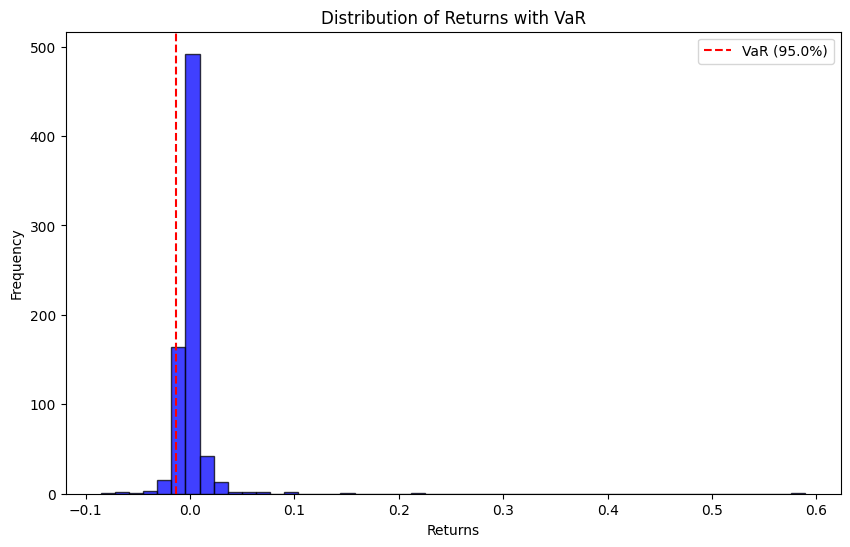

1Y Value at Risk (VaR) at 95.0% confidence level is -21.23%
Conditional Value at Risk (CVaR) at 95.0% confidence level is -2.52%


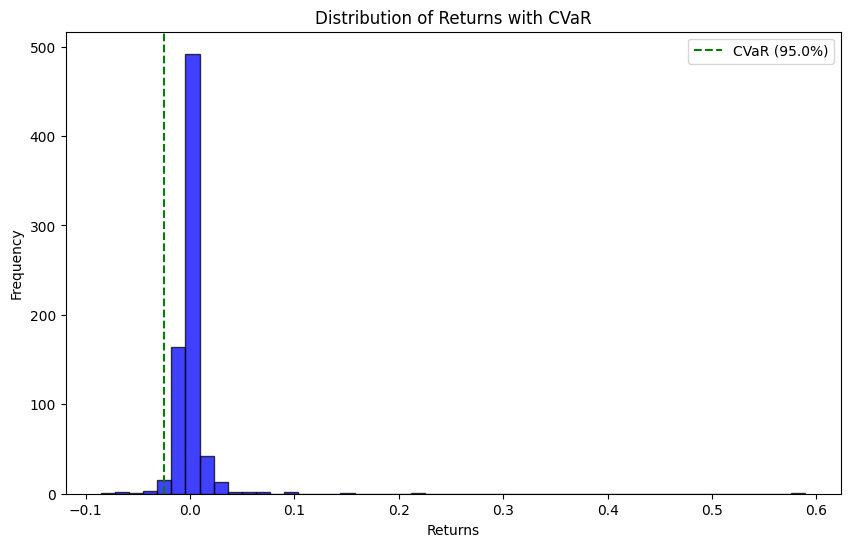

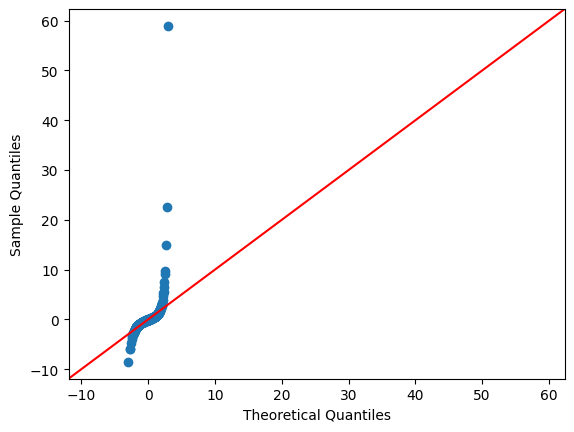

The data is not normally distributed (Shapiro)
The data is not normally distributed (K-S)


In [11]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import shapiro, kstest

# Загружаем файл
file_path = "/Users/contessina/Documents/my_projects/RR/data/test_local.xlsx"
df = pd.read_excel(file_path)

# Преобразуем столбец "СЧА (₽)" в числовой формат
df['СЧА'] = df['СЧА (₽)'].astype(str).str.replace(" ", "").str.replace(",", ".").astype(float)

# Считаем дневные изменения
df['ΔLAST за день, %'] = df['СЧА'].sort_index(ascending=False).pct_change().dropna()

returns = df['ΔLAST за день, %'].iloc[:-1]

# --- VaR ---
confidence_level = 0.95
var = np.percentile(returns, (1 - confidence_level) * 100)
print(f"Value at Risk (VaR) at {confidence_level*100}% confidence level is {var:.2%}")

plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, alpha=0.75, color='blue', edgecolor='black')
plt.axvline(x=var, color='red', linestyle='--', label=f'VaR ({confidence_level*100}%)')
plt.title('Distribution of Returns with VaR')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# --- Annualized VaR ---
period = 252
var_1y = var * math.sqrt(period)
print(f"1Y Value at Risk (VaR) at {confidence_level*100}% confidence level is {var_1y:.2%}")

# --- CVaR ---
var_threshold = np.percentile(returns, (1 - confidence_level) * 100)
tail_losses = returns[returns < var_threshold]
cvar = tail_losses.mean()
print(f"Conditional Value at Risk (CVaR) at {confidence_level*100}% confidence level is {cvar:.2%}")

plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, alpha=0.75, color='blue', edgecolor='black')
plt.axvline(x=cvar, color='green', linestyle='--', label=f'CVaR ({confidence_level*100}%)')
plt.title('Distribution of Returns with CVaR')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# --- Q-Q plot ---
fig = sm.qqplot(returns*100, line='45')
plt.show()

# --- Normality Tests ---
if shapiro(returns*100)[1] <= 0.05:
    print('The data is not normally distributed (Shapiro)')
else:
    print('The data is normally distributed (Shapiro)')

if kstest(returns*100, 'norm')[1] <= 0.05:
    print('The data is not normally distributed (K-S)')
else:
    print('The data is normally distributed (K-S)')


Value at Risk (VaR) at 95.0% confidence level is -3.08%


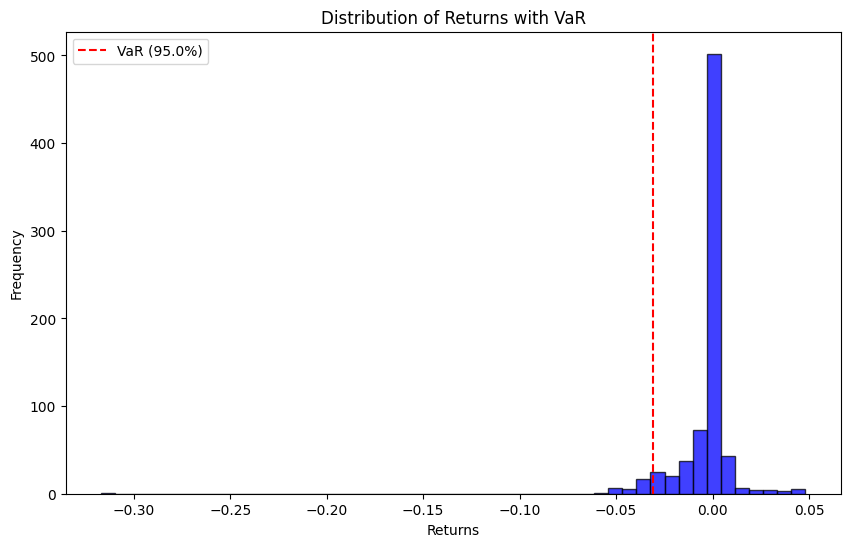

1Y Value at Risk (VaR) at 95.0% confidence level is -48.88%
Conditional Value at Risk (CVaR) at 95.0% confidence level is -4.66%


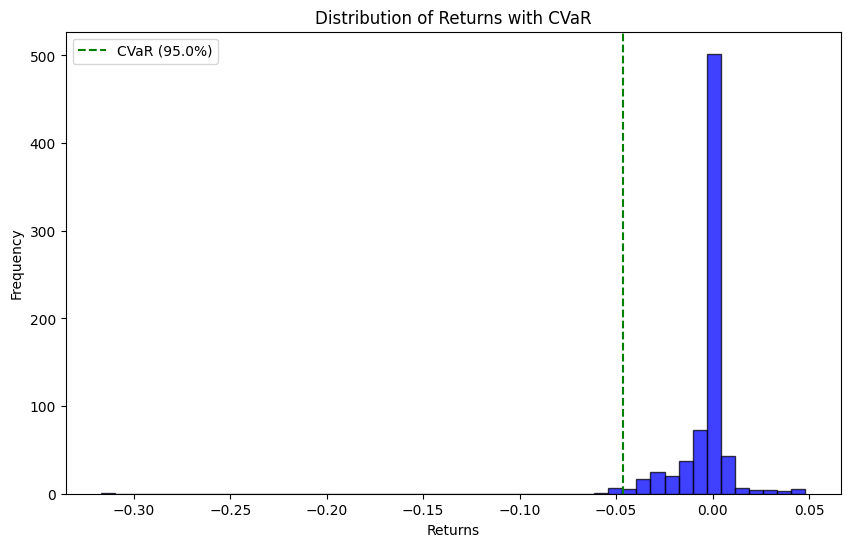

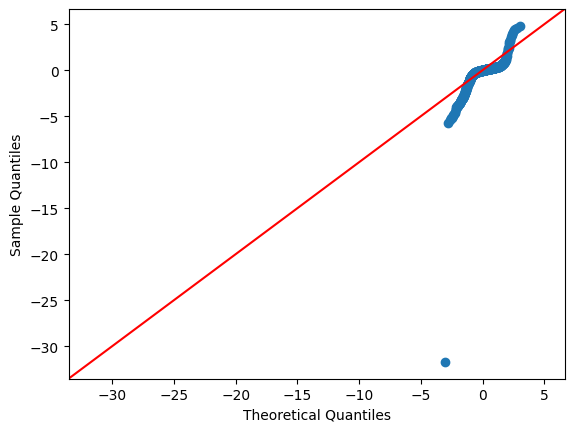

The data is not normally distributed (Shapiro)
The data is not normally distributed (K-S)


In [12]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import shapiro, kstest

# Загружаем файл
file_path = "/Users/contessina/Documents/my_projects/RR/data/test_russian_bonds.xlsx"
df = pd.read_excel(file_path)

# Преобразуем столбец "СЧА (₽)" в числовой формат
df['СЧА'] = df['СЧА (₽)'].astype(str).str.replace(" ", "").str.replace(",", ".").astype(float)

# Считаем дневные изменения
df['ΔLAST за день, %'] = df['СЧА'].sort_index(ascending=False).pct_change().dropna()

returns = df['ΔLAST за день, %'].iloc[:-1]

# --- VaR ---
confidence_level = 0.95
var = np.percentile(returns, (1 - confidence_level) * 100)
print(f"Value at Risk (VaR) at {confidence_level*100}% confidence level is {var:.2%}")

plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, alpha=0.75, color='blue', edgecolor='black')
plt.axvline(x=var, color='red', linestyle='--', label=f'VaR ({confidence_level*100}%)')
plt.title('Distribution of Returns with VaR')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# --- Annualized VaR ---
period = 252
var_1y = var * math.sqrt(period)
print(f"1Y Value at Risk (VaR) at {confidence_level*100}% confidence level is {var_1y:.2%}")

# --- CVaR ---
var_threshold = np.percentile(returns, (1 - confidence_level) * 100)
tail_losses = returns[returns < var_threshold]
cvar = tail_losses.mean()
print(f"Conditional Value at Risk (CVaR) at {confidence_level*100}% confidence level is {cvar:.2%}")

plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, alpha=0.75, color='blue', edgecolor='black')
plt.axvline(x=cvar, color='green', linestyle='--', label=f'CVaR ({confidence_level*100}%)')
plt.title('Distribution of Returns with CVaR')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# --- Q-Q plot ---
fig = sm.qqplot(returns*100, line='45')
plt.show()

# --- Normality Tests ---
if shapiro(returns*100)[1] <= 0.05:
    print('The data is not normally distributed (Shapiro)')
else:
    print('The data is normally distributed (Shapiro)')

if kstest(returns*100, 'norm')[1] <= 0.05:
    print('The data is not normally distributed (K-S)')
else:
    print('The data is normally distributed (K-S)')


Value at Risk (VaR) at 95.0% confidence level is -2.15%


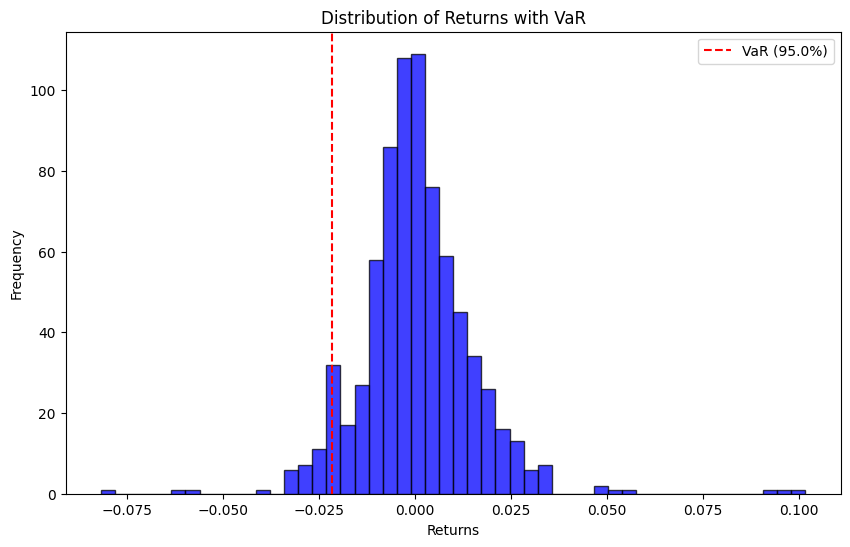

1Y Value at Risk (VaR) at 95.0% confidence level is -34.21%
Conditional Value at Risk (CVaR) at 95.0% confidence level is -2.94%


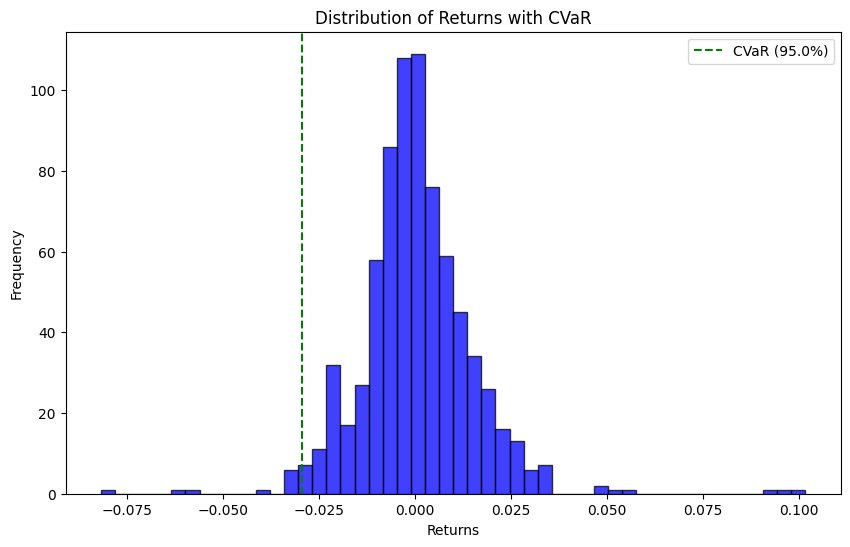

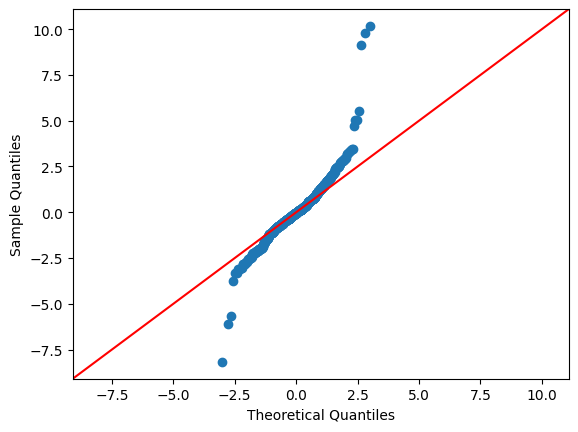

The data is not normally distributed (Shapiro)
The data is not normally distributed (K-S)


In [13]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import shapiro, kstest

# Загружаем файл
file_path = "/Users/contessina/Documents/my_projects/RR/data/test_russian_shares.xlsx"
df = pd.read_excel(file_path)

# Преобразуем столбец "СЧА (₽)" в числовой формат
df['СЧА'] = df['СЧА (₽)'].astype(str).str.replace(" ", "").str.replace(",", ".").astype(float)

# Считаем дневные изменения
df['ΔLAST за день, %'] = df['СЧА'].sort_index(ascending=False).pct_change().dropna()

returns = df['ΔLAST за день, %'].iloc[:-1]

# --- VaR ---
confidence_level = 0.95
var = np.percentile(returns, (1 - confidence_level) * 100)
print(f"Value at Risk (VaR) at {confidence_level*100}% confidence level is {var:.2%}")

plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, alpha=0.75, color='blue', edgecolor='black')
plt.axvline(x=var, color='red', linestyle='--', label=f'VaR ({confidence_level*100}%)')
plt.title('Distribution of Returns with VaR')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# --- Annualized VaR ---
period = 252
var_1y = var * math.sqrt(period)
print(f"1Y Value at Risk (VaR) at {confidence_level*100}% confidence level is {var_1y:.2%}")

# --- CVaR ---
var_threshold = np.percentile(returns, (1 - confidence_level) * 100)
tail_losses = returns[returns < var_threshold]
cvar = tail_losses.mean()
print(f"Conditional Value at Risk (CVaR) at {confidence_level*100}% confidence level is {cvar:.2%}")

plt.figure(figsize=(10, 6))
plt.hist(returns, bins=50, alpha=0.75, color='blue', edgecolor='black')
plt.axvline(x=cvar, color='green', linestyle='--', label=f'CVaR ({confidence_level*100}%)')
plt.title('Distribution of Returns with CVaR')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# --- Q-Q plot ---
fig = sm.qqplot(returns*100, line='45')
plt.show()

# --- Normality Tests ---
if shapiro(returns*100)[1] <= 0.05:
    print('The data is not normally distributed (Shapiro)')
else:
    print('The data is normally distributed (Shapiro)')

if kstest(returns*100, 'norm')[1] <= 0.05:
    print('The data is not normally distributed (K-S)')
else:
    print('The data is normally distributed (K-S)')
